# Tahap 1 - Bussiness & Data Understanding

In [72]:
# ===========================================================================
# CRISP-DM TAHAP 1 & 2: BUSINESS & DATA UNDERSTANDING
# ===========================================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

print("=== 1. DEFINISI PARAMETER & LOAD DATA ===")

# SUB-TAHAP: LOAD DATA ASLI
df = pd.read_excel('dataset_atribut_clustering.xlsx')

# SUB-TAHAP: DEFINISI KOLOM
kolom_identitas = [
    'kode_kecamatan',
    'kabupaten_kota',
    'kecamatan'
]

fitur_cols = [
    'persen_pilpres',
    'persen_pileg_ri',
    'persen_pileg_prov',
    'persen_pileg_kokab',
    'persen_pilgub',
    'persen_pilwalbup',
    'persen_part_pilpres',
    'persen_part_pileg_ri',
    'persen_part_pileg_prov',
    'persen_part_pileg_kokab',
    'persen_part_pilgub',
    'persen_part_pilwalbup',
    'persen_baseline_pilwalbup'
]

print(f"Data berhasil dimuat: {df.shape[0]} baris")
print("Jumlah fitur klastering:", len(fitur_cols))

=== 1. DEFINISI PARAMETER & LOAD DATA ===
Data berhasil dimuat: 627 baris
Jumlah fitur klastering: 13


# Tahap 2 - Data Understanding

In [73]:
# ===========================================================================
# CRISP-DM TAHAP 1 & 2: BUSINESS & DATA UNDERSTANDING
# ===========================================================================
print("=== 2. DATA UNDERSTANDING ===")

kolom_tabel = kolom_identitas + fitur_cols

# SUB-TAHAP: RINGKASAN STRUKTUR DATA
tabel = pd.DataFrame({
    'Column': kolom_tabel,
    'Non-Null Count': [f"{df[c].notnull().sum()} non-null" for c in kolom_tabel],
    'Dtype': [str(df[c].dtype) for c in kolom_tabel],
    'Missing Value': [df[c].isnull().sum() for c in kolom_tabel]
})

tabel.insert(0, 'No', range(1, len(tabel)+1))
print(tabel.to_string(index=False))

# SUB-TAHAP: EXPORT LAPORAN
nama_file = "Data_Understanding_Struktur_dan_Kelengkapan.xlsx"
tabel.to_excel(nama_file, index=False)
print(f"\n[INFO] Berkas laporan berhasil disimpan: {nama_file}")

=== 2. DATA UNDERSTANDING ===
 No                    Column Non-Null Count   Dtype  Missing Value
  1            kode_kecamatan   627 non-null   int64              0
  2            kabupaten_kota   627 non-null     str              0
  3                 kecamatan   627 non-null     str              0
  4            persen_pilpres   627 non-null float64              0
  5           persen_pileg_ri   627 non-null float64              0
  6         persen_pileg_prov   627 non-null float64              0
  7        persen_pileg_kokab   627 non-null float64              0
  8             persen_pilgub   627 non-null float64              0
  9          persen_pilwalbup   627 non-null float64              0
 10       persen_part_pilpres   627 non-null float64              0
 11      persen_part_pileg_ri   627 non-null float64              0
 12    persen_part_pileg_prov   627 non-null float64              0
 13   persen_part_pileg_kokab   627 non-null float64              0
 14        persen_

# Tahap 3 - Data Preparation (Z-Score)

In [74]:
# ===========================================================================
# CRISP-DM TAHAP 3: DATA PREPARATION (Z-SCORE SCALING)
# ===========================================================================
print("=== 3. DATA PREPARATION (Z-SCORE) ===")

# SUB-TAHAP: PROSES NORMALISASI
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[fitur_cols])
X_scaled = X_scaled.round(3)

# SUB-TAHAP: PENYUSUNAN DATAFRAME FINAL
df_final = pd.DataFrame(X_scaled, columns=fitur_cols)
df_final.insert(0, 'kecamatan', df['kecamatan'].values)
df_final.insert(0, 'kabupaten_kota', df['kabupaten_kota'].values)
df_final.insert(0, 'kode_kecamatan', df['kode_kecamatan'].values)

# SUB-TAHAP: TAMPILAN SAMPEL & VERIFIKASI
print("Tampilan 10 baris sampel acak (random sample) hasil normalisasi:")
df_sample = df_final.sample(10, random_state=42)
display(df_sample)

print("\nVerifikasi Statistik (Mean harus ~0 dan Std harus ~1):")
df_verifikasi = df_final[fitur_cols].describe().round(3).loc[['mean', 'std']]
display(df_verifikasi)

# SUB-TAHAP: EXPORT MULTI-SHEET
nama_file_t2 = "Hasil_Normalisasi_ZScore.xlsx"
with pd.ExcelWriter(nama_file_t2, engine='openpyxl') as writer:
    df_final.to_excel(writer, sheet_name='Data_Normalisasi', index=False)
    df_sample.to_excel(writer, sheet_name='Sample_Random', index=False)
    df_verifikasi.to_excel(writer, sheet_name='Verifikasi_Statistik')

=== 3. DATA PREPARATION (Z-SCORE) ===
Tampilan 10 baris sampel acak (random sample) hasil normalisasi:


,kode_kecamatan,kabupaten_kota,kecamatan,persen_pilpres,persen_pileg_ri,persen_pileg_prov,persen_pileg_kokab,persen_pilgub,persen_pilwalbup,persen_part_pilpres,persen_part_pileg_ri,persen_part_pileg_prov,persen_part_pileg_kokab,persen_part_pilgub,persen_part_pilwalbup,persen_baseline_pilwalbup
580,327329,KOTA BANDUNG,CINAMBO,-0.219,-0.695,-0.610,-0.198,0.115,-0.325,1.111,1.041,1.003,1.012,0.366,0.405,-0.929
590,327504,KOTA BEKASI,BEKASI SELATAN,-1.474,-0.939,-0.917,0.045,-1.801,-0.021,-0.085,-0.229,-0.199,-0.169,-1.621,-1.568,-0.422
550,327206,KOTA SUKABUMI,LEMBURSITU,-0.708,-0.063,-0.504,-1.321,0.106,-0.764,0.230,0.278,0.268,0.286,0.498,0.543,-0.422
213,320622,TASIKMALAYA,MANONJAYA,-0.969,1.367,1.459,0.673,-0.807,0.551,0.027,0.039,0.036,0.045,0.474,-0.268,-0.422
485,321526,KARAWANG,KARAWANG TIMUR,0.359,0.876,0.867,0.422,1.315,0.226,0.319,0.321,0.309,0.319,0.286,0.307,0.592
235,320705,CIAMIS,CIDOLOG,-0.635,-0.850,-1.301,-1.075,-0.966,2.502,-0.358,-0.317,-0.306,-0.295,0.634,0.678,3.633
453,321411,PURWAKARTA,BOJONG,0.700,1.667,-0.026,-1.178,2.021,0.774,0.891,0.956,0.921,0.956,1.289,1.331,-0.929
77,320238,SUKABUMI,PURABAYA,-0.517,-0.043,-0.247,-0.163,-1.200,-0.296,-1.733,-1.734,-1.671,-1.702,-2.059,-2.005,0.592
529,321801,PANGANDARAN,PARIGI,-0.726,-0.463,-0.854,-0.637,0.381,0.043,1.187,1.220,1.175,1.211,2.245,2.272,0.592
145,320438,BANDUNG,PASIRJAMBU,1.188,-0.518,-0.975,-0.584,1.346,0.643,0.796,0.859,0.917,0.864,1.130,1.170,0.592



Verifikasi Statistik (Mean harus ~0 dan Std harus ~1):


,persen_pilpres,persen_pileg_ri,persen_pileg_prov,persen_pileg_kokab,persen_pilgub,persen_pilwalbup,persen_part_pilpres,persen_part_pileg_ri,persen_part_pileg_prov,persen_part_pileg_kokab,persen_part_pilgub,persen_part_pilwalbup,persen_baseline_pilwalbup
mean,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


# Tahap 4 - Modeling

In [75]:
# ===========================================================================
# CRISP-DM TAHAP 4: MODELING (ELBOW METHOD)
# ===========================================================================
print("=== 4. MODELING & EVALUASI NILAI K ===")

X_scaled_data = df_final[fitur_cols]

# SUB-TAHAP: UJI KANDIDAT NILAI K (2-10)
k_range = range(2, 11)
list_sse = []
list_silhouette = []
list_dbi = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled_data)
    list_sse.append(model.inertia_)
    list_silhouette.append(silhouette_score(X_scaled_data, labels))
    list_dbi.append(davies_bouldin_score(X_scaled_data, labels))

# SUB-TAHAP: TABEL VALIDASI
tabel_validasi_k = pd.DataFrame({
    'K': list(k_range),
    'SSE': list_sse,
    'Silhouette Score': list_silhouette,
    'Davies-Bouldin Index': list_dbi
}).round(3)

print("\n=== TABEL HASIL VALIDASI NILAI K ===")
display(tabel_validasi_k)

tabel_validasi_k.to_excel("Hasil_Validasi_Nilai_K.xlsx", index=False)

=== 4. MODELING & EVALUASI NILAI K ===

=== TABEL HASIL VALIDASI NILAI K ===


,K,SSE,Silhouette Score,Davies-Bouldin Index
0,2,5878.469,0.247,1.499
1,3,5026.085,0.194,1.689
2,4,4487.592,0.212,1.422
3,5,3964.373,0.210,1.380
4,6,3663.325,0.203,1.432
5,7,3425.648,0.203,1.406
6,8,3233.485,0.187,1.521
7,9,3078.456,0.194,1.459
8,10,2900.810,0.191,1.449


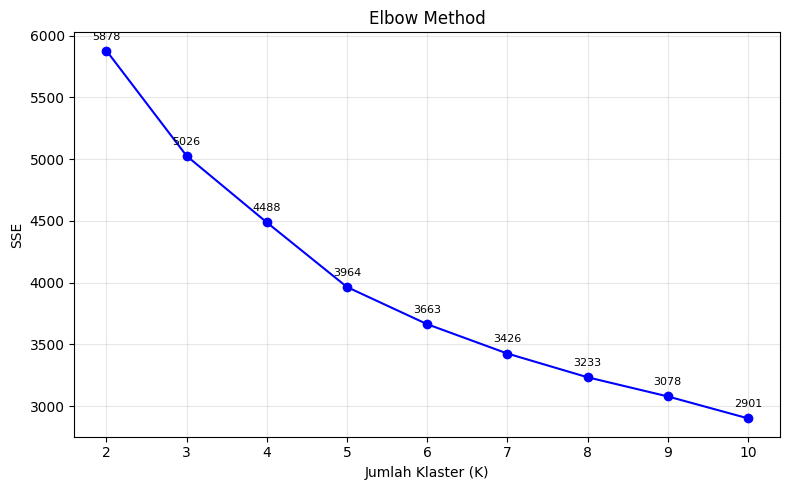

In [76]:
# ===========================================================================
# CRISP-DM TAHAP 4: MODELING (SILHOUETTE SCORE)
# ===========================================================================
# --- GRAFIK ELBOW METHOD ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), list_sse, marker='o', color='blue')
for x, y in zip(list(k_range), list_sse):
    plt.annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=8)
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("Grafik_Elbow_Method.png", dpi=300)
plt.show()

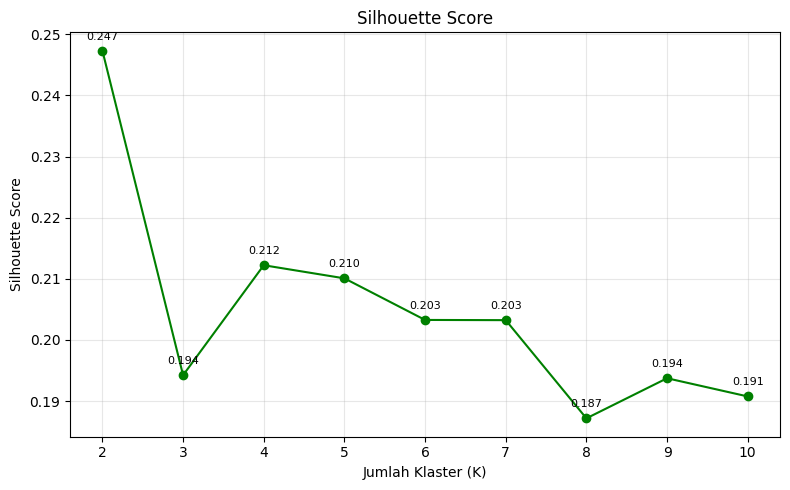

In [77]:
# ===========================================================================
# CRISP-DM TAHAP 4: MODELING (DAVIES-BOULDIN INDEX)
# ===========================================================================
# --- GRAFIK SILHOUETTE SCORE ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), list_silhouette, marker='o', color='green')
for x, y in zip(list(k_range), list_silhouette):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=8)
plt.title('Silhouette Score')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("Grafik_Silhouette_Score.png", dpi=300)
plt.show()

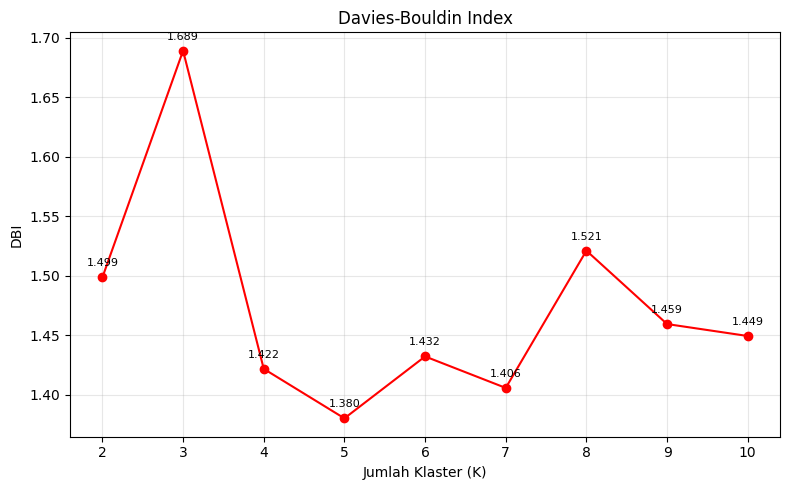

In [78]:
# ===========================================================================
# CRISP-DM TAHAP 4: MODELING (OPTIMAL K SELECTION)
# ===========================================================================
# --- GRAFIK DAVIES-BOULDIN INDEX ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), list_dbi, marker='o', color='red')
for x, y in zip(list(k_range), list_dbi):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=8)
plt.title('Davies-Bouldin Index')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('DBI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("Grafik_Davies_Bouldin_Index.png", dpi=300)
plt.show()

# Tahap 5 - Evaluation

In [68]:
# ===========================================================================
# CRISP-DM TAHAP 5: EVALUATION (HASIL KLASTER FINAL & CROSSTAB)
# ===========================================================================
from sklearn.cluster import KMeans


# SUB-TAHAP: K-MEANS FINAL
k_final = 5
X_scaled = df_final[fitur_cols]

model_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_final['cluster_label'] = model_final.fit_predict(X_scaled)

# SUB-TAHAP: REKAP DISTRIBUSI KLASTER
rekap_klaster = (
    df_final['cluster_label']
    .value_counts()
    .sort_index()
    .reset_index()
)

rekap_klaster.columns = ['cluster_label', 'jumlah_kecamatan']
rekap_klaster['persentase_kecamatan'] = (
    rekap_klaster['jumlah_kecamatan'] / len(df_final) * 100
).round(2)

print(rekap_klaster.to_string(index=False))

# SUB-TAHAP: TABEL PENGELOMPOKAN
tabel_kokab_cluster = pd.crosstab(
    df_final['kabupaten_kota'],
    df_final['cluster_label']
).reset_index()
# # Ganti bagian ini agar otomatis mengikuti jumlah k_final
tabel_kokab_cluster.columns = ['kabupaten_kota'] + [f'Klaster {i+1}' for i in range(k_final)]
print("\n=== TABEL PENGELOMPOKAN BERDASARKAN KABUPATEN/KOTA ===")
print(tabel_kokab_cluster.to_string(index=False))

# SUB-TAHAP: EXPORT HASIL CLUSTERING
nama_file_cluster = f"Hasil_Clustering_Final_K{k_final}.xlsx"

with pd.ExcelWriter(nama_file_cluster, engine='openpyxl') as writer:
    df_final.to_excel(writer, sheet_name='Hasil_Cluster', index=False)
    rekap_klaster.to_excel(writer, sheet_name='Distribusi_Klaster', index=False)
    tabel_kokab_cluster.to_excel(writer, sheet_name='Cluster_per_KabKota', index=False)

print(f"\n[INFO] File berhasil disimpan: {nama_file_cluster}")

 cluster_label  jumlah_kecamatan  persentase_kecamatan
             0               202                 32.22
             1               143                 22.81
             2               157                 25.04
             3                27                  4.31
             4                98                 15.63

=== TABEL PENGELOMPOKAN BERDASARKAN KABUPATEN/KOTA ===
  kabupaten_kota  Klaster 1  Klaster 2  Klaster 3  Klaster 4  Klaster 5
         BANDUNG          4         27          0          0          0
   BANDUNG BARAT          3         10          0          0          3
          BEKASI          9          3          0          0         11
           BOGOR         23          3          0          0         14
          CIAMIS          0          0          0         27          0
         CIANJUR          5          0         27          0          0
         CIREBON         19          0         20          0          1
           GARUT         18         15

Tabel 1 (6 Parameter Pertama - Perolehan):


,cluster_label,jumlah_kecamatan,persen_pilpres,persen_pileg_ri,persen_pileg_prov,persen_pileg_kokab,persen_pilgub,persen_pilwalbup
0,0,202,54.141,13.848,14.857,12.793,57.497,44.232
1,1,143,64.912,13.402,14.889,11.358,68.953,51.681
2,2,157,59.923,16.724,16.730,15.846,59.414,35.179
3,3,27,49.692,14.330,11.845,11.503,56.904,89.899
4,4,98,64.717,25.246,25.469,21.366,68.768,51.819



Tabel 2 (7 Parameter Selanjutnya - Partisipasi):


,cluster_label,jumlah_kecamatan,persen_part_pilpres,persen_part_pileg_ri,persen_part_pileg_prov,persen_part_pileg_kokab,persen_part_pilgub,persen_part_pilwalbup,persen_baseline_pilwalbup
0,0,202,82.544,82.027,81.973,81.925,64.397,63.853,36.906
1,1,143,85.380,85.202,85.315,85.231,74.405,74.376,39.499
2,2,157,75.182,75.067,74.965,74.947,60.196,59.707,36.412
3,3,27,80.685,80.507,81.005,80.109,71.046,70.940,100.000
4,4,98,84.740,84.491,84.470,84.406,70.891,70.551,38.044


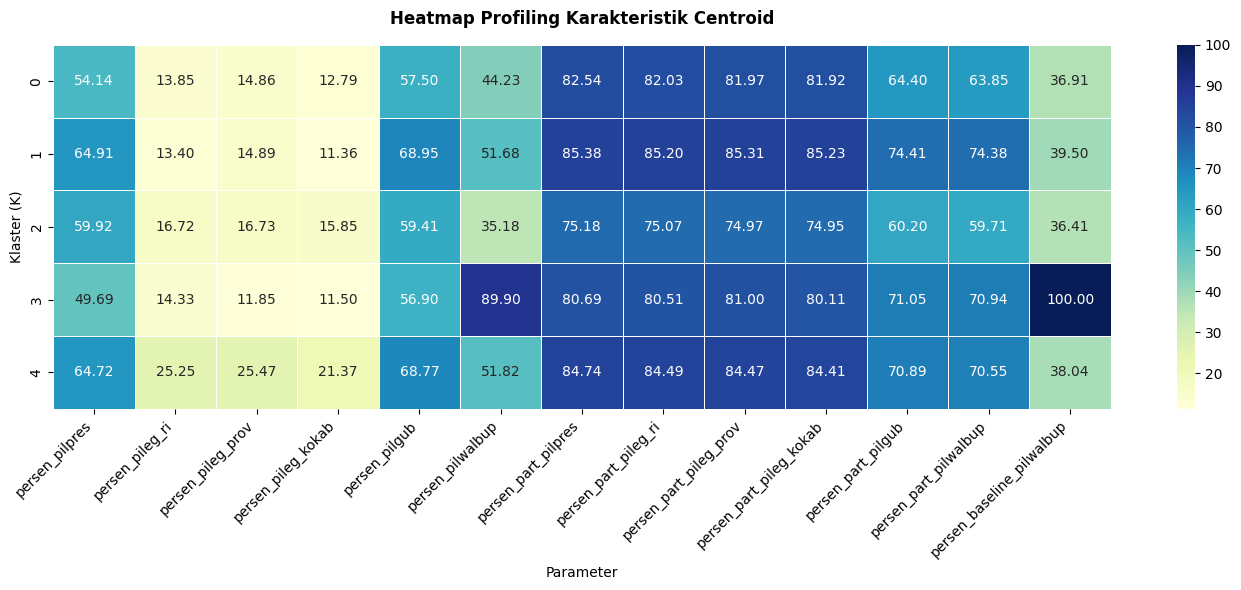


[INFO] Berkas profiling berhasil disimpan dalam file: Hasil_Profiling_Centroid.xlsx


In [ ]:
# ===========================================================================
# CRISP-DM TAHAP 5: EVALUATION (CLUSTER PROFILING & HEATMAP)
# ===========================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# SUB-TAHAP: MAPPING LABEL KLASTER KE DATA ASLI
df['cluster_label'] = df_final['cluster_label']

# SUB-TAHAP: HITUNG RATA-RATA ATRIBUT PER KLASTER
tabel_profiling = df.groupby('cluster_label')[fitur_cols].mean().round(3)

# SUB-TAHAP: HITUNG DISTRIBUSI JUMLAH KECAMATAN
jumlah_per_klaster = df['cluster_label'].value_counts().sort_index()

# SUB-TAHAP: GABUNGKAN DATA PROFILING
tabel_profiling = tabel_profiling.reset_index()
# # Pastikan insert tidak error jika kolom sudah ada
if 'jumlah_kecamatan' in tabel_profiling.columns:
    tabel_profiling = tabel_profiling.drop(columns=['jumlah_kecamatan'])
tabel_profiling.insert(1, 'jumlah_kecamatan', jumlah_per_klaster.values)

# SUB-TAHAP: PISAHKAN MENJADI 2 TABEL (6 Parameter & 7 Parameter)
# # Ambil kolom parameter dari list fitur_cols
tabel_1 = tabel_profiling[['cluster_label', 'jumlah_kecamatan'] + fitur_cols[:6]]
tabel_2 = tabel_profiling[['cluster_label', 'jumlah_kecamatan'] + fitur_cols[6:]]

print("Tabel 1 (6 Parameter Pertama - Perolehan):")
display(tabel_1)

print("\nTabel 2 (7 Parameter Selanjutnya - Partisipasi):")
display(tabel_2)

# SUB-TAHAP: VISUALISASI HEATMAP UNTUK PROFILING
plt.figure(figsize=(14, 6))

df_heatmap = tabel_profiling.set_index('cluster_label')[fitur_cols]

sns.heatmap(df_heatmap, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Heatmap Profiling Karakteristik Centroid', pad=15, fontweight='bold')
plt.ylabel('Klaster (K)')
plt.xlabel('Parameter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig("Grafik_Heatmap_Profiling.png", dpi=300)
plt.show()

# SUB-TAHAP: EKSPOR HASIL PROFILING MULTI-SHEET
nama_file_profiling = "Hasil_Profiling_Centroid.xlsx"
with pd.ExcelWriter(nama_file_profiling, engine='openpyxl') as writer:
    tabel_profiling.to_excel(writer, sheet_name='Semua_Parameter', index=False)
    tabel_1.to_excel(writer, sheet_name='Tabel_1_Perolehan', index=False)
    tabel_2.to_excel(writer, sheet_name='Tabel_2_Partisipasi', index=False)

print(f"\n[INFO] Berkas profiling berhasil disimpan dalam file: {nama_file_profiling}")

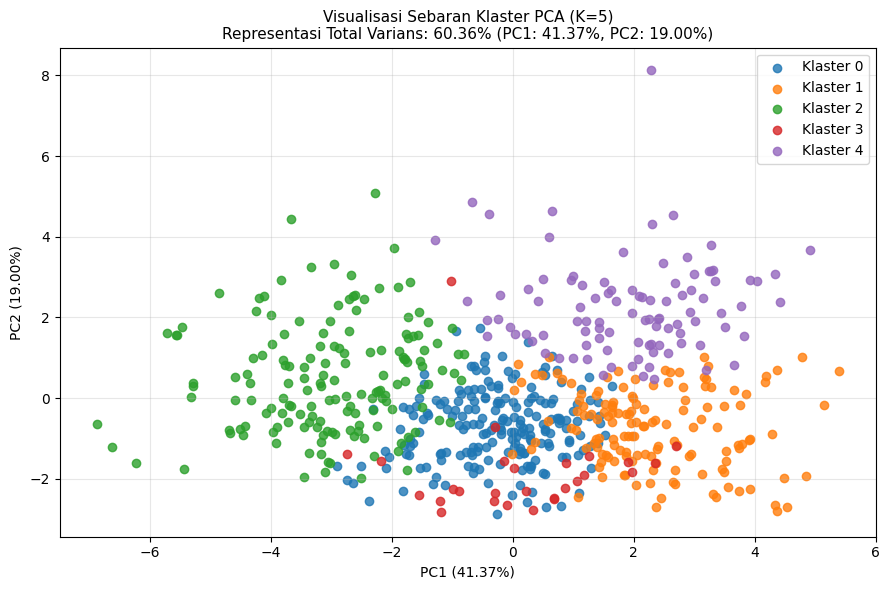

=== TABEL KONTRIBUSI INDIKATOR PEMBENTUK SUMBU PCA ===
-----------------------------------------------------------------------------------------------
                           Korelasi_PC1  Korelasi_PC2 Komponen_Dominan
persen_pilpres                   0.1224        0.1937              PC2
persen_pileg_ri                  0.0459        0.5389              PC2
persen_pileg_prov                0.0670        0.5564              PC2
persen_pileg_kokab              -0.0041        0.5340              PC2
persen_pilgub                    0.2350        0.1973              PC1
persen_pilwalbup                 0.1323       -0.0221              PC1
persen_part_pilpres              0.4039       -0.0481              PC1
persen_part_pileg_ri             0.4108       -0.0431              PC1
persen_part_pileg_prov           0.4028       -0.0409              PC1
persen_part_pileg_kokab          0.4088       -0.0420              PC1
persen_part_pilgub               0.3464       -0.0717              P

In [70]:
# ===========================================================================
# CRISP-DM TAHAP 5: EVALUATION (PCA & DIMENSIONALITY REDUCTION)
# ===========================================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# # Cetakan teks representasi dipindahkan ke dalam sub-judul grafik

# --- PERHITUNGAN PCA ---
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# # Hitung Persentase Varians yang dijelaskan
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
total_var = var_pc1 + var_pc2





df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_final.index)
df_pca['cluster_label'] = df_final['cluster_label']

plt.figure(figsize=(9, 6))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, cluster in enumerate(sorted(df_pca['cluster_label'].unique())):
    subset = df_pca[df_pca['cluster_label'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Klaster {cluster}', alpha=0.8, color=colors[i % len(colors)])

plt.title(f'Visualisasi Sebaran Klaster PCA (K={k_final})\nRepresentasi Total Varians: {total_var:.2f}% (PC1: {var_pc1:.2f}%, PC2: {var_pc2:.2f}%)', fontsize=11)
plt.xlabel(f'PC1 ({var_pc1:.2f}%)')
plt.ylabel(f'PC2 ({var_pc2:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"Visualisasi_PCA_K{k_final}.png", dpi=300)
plt.show()

# --- TABEL NILAI ---
print("=== TABEL KONTRIBUSI INDIKATOR PEMBENTUK SUMBU PCA ===")
print("-" * 95)
# pca.components_ berisi nilai loadings (eigenvectors) untuk setiap Principal Component
loadings = pd.DataFrame(
    pca.components_.T,  
    columns=['Korelasi_PC1', 'Korelasi_PC2'],
    index=fitur_cols
)

# # Menentukan komponen mana yang lebih dominan secara absolut bagi fitur tersebut
loadings['Komponen_Dominan'] = loadings.apply(
    lambda row: 'PC1' if abs(row['Korelasi_PC1']) > abs(row['Korelasi_PC2']) else 'PC2', 
    axis=1
)

print(loadings.round(4).to_string())
print("-" * 95)
loadings.to_excel("Hasil_Eigenvector_PCA_Loadings.xlsx")
print("\n[INFO] Tabel Nilai Eigenvector pembentuk PCA berhasil diekspor: Hasil_Eigenvector_PCA_Loadings.xlsx")

=== PERBANDINGAN NILAI ASLI (%) KECAMATAN INDIKATOR BATAS ===
--------------------------------------------------------------------------------------------------------------
                          CIATER\n(Max PC1 (Kanan)) KARANG KANCANA\n(Min PC1 (Kiri)) BABAKAN MADANG\n(Max PC2 (Atas)) PASEKAN\n(Min PC2 (Bawah))
persen_pilpres                                73.89                            51.12                            69.78                      72.94
persen_pileg_ri                               17.63                            12.71                            44.54                       4.34
persen_pileg_prov                             18.26                            10.62                            46.23                       6.05
persen_pileg_kokab                            20.02                            10.64                            46.23                       3.61
persen_pilgub                                 74.18                            57.34                  

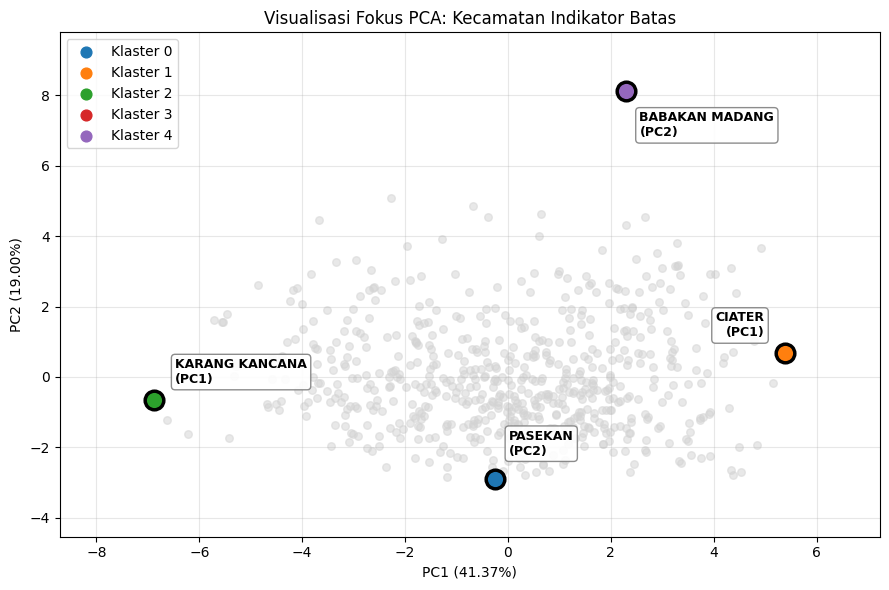


[INFO] Tabel Indikator Batas berhasil diekspor: Hasil_Perbandingan_Boundary_PCA.xlsx


In [71]:
# ===========================================================================
# CRISP-DM TAHAP 5: EVALUATION (BOUNDARY & OUTLIER ANALYSIS)
# ===========================================================================

# --- IDENTIFIKASI BOUNDARY INDICATORS (KECAMATAN EKSTREM) ---
outliers = {
    "Max PC1 (Kanan)": df_pca['PC1'].idxmax(),
    "Min PC1 (Kiri)": df_pca['PC1'].idxmin(),
    "Max PC2 (Atas)": df_pca['PC2'].idxmax(),
    "Min PC2 (Bawah)": df_pca['PC2'].idxmin()
}

# --- TABEL PERBANDINGAN NILAI ASLI (%) ---
print("=== PERBANDINGAN NILAI ASLI (%) KECAMATAN INDIKATOR BATAS ===")
print("-" * 110)

comparison_data = {}
for label, idx in outliers.items():
    col_name = f"{df.loc[idx, 'kecamatan']}\n({label})"
# # AMBIL DARI 'df' (Data Asli) & BULATKAN 2 ANGKA
    comparison_data[col_name] = df.loc[idx, fitur_cols].astype(float).round(2)

df_compare = pd.DataFrame(comparison_data)

# # Info Tambahan: Klaster & Lokasi
df_compare.loc['[KAB_KOTA]'] = [df.loc[outliers[k], 'kabupaten_kota'] for k in outliers]
df_compare.loc['[CLUSTER]'] = [f"Klaster {df_final.loc[outliers[k], 'cluster_label']}" for k in outliers]

print(df_compare.to_string())
print("-" * 110)

plt.figure(figsize=(9, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# # Agar plot "titik biasa" tidak mencolok, kita plot dengan abu-abu
for i, cluster in enumerate(sorted(df_pca['cluster_label'].unique())):
    subset = df_pca[df_pca['cluster_label'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], color='lightgrey', alpha=0.5, s=30)

# # Legenda bayangan, agar tetap ada panutan warna
for i, cluster in enumerate(sorted(df_pca['cluster_label'].unique())):
    plt.scatter([], [], label=f'Klaster {cluster}', color=colors[i % len(colors)], s=60)

# # Soroti Titik Ekstrem
for label, idx in outliers.items():
    p = df_pca.loc[idx]
    c_idx = int(p['cluster_label'])
    nama_kec = df.loc[idx, 'kecamatan']
    
# # Titik lebih besar & Bold
    plt.scatter(p['PC1'], p['PC2'], color=colors[c_idx % len(colors)], 
                s=180, edgecolors='black', linewidth=2.5, zorder=10)
    
# # Atur posisi kotak label secara dinamis agar tidak ketutupan!
    offset_x = 10
    offset_y = 10
    ha = 'left'
    va = 'bottom'
    
    if 'Max PC1' in label:
        offset_x = -15
        ha = 'right'
    if 'Min PC1' in label:
        offset_x = 15
        ha = 'left'
    if 'Max PC2' in label:
        offset_y = -15
        va = 'top'
    if 'Min PC2' in label:
        offset_y = 15
        va = 'bottom'
        
# # Label
    plt.annotate(f"{nama_kec}\n({label.split(' ')[1]})", 
                 (p['PC1'], p['PC2']),
                 xytext=(offset_x, offset_y), textcoords='offset points',
                 ha=ha, va=va,
                 fontsize=9, fontweight='bold', 
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.9),
                 zorder=11)

# # Beri margin/padding ekstra sebesar 20% agar label paling pinggir tidak terpotong garis plot
plt.margins(x=0.15, y=0.15)

plt.title(f'Visualisasi Fokus PCA: Kecamatan Indikator Batas')
plt.xlabel(f'PC1 ({var_pc1:.2f}%)')
plt.ylabel(f'PC2 ({var_pc2:.2f}%)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Visualisasi_PCA_Fokus_Indikator Batas.png", dpi=300)
plt.show()

# --- EXPORT TABEL PERBANDINGAN KE EXCEL ---
df_compare.to_excel("Hasil_Perbandingan_Boundary_PCA.xlsx")
print(f"\n[INFO] Tabel Indikator Batas berhasil diekspor: Hasil_Perbandingan_Boundary_PCA.xlsx")